# 02 · La caja no es MRR: huecos de pago, puestas al día y el churn que no es churn

**Pregunta.** El modelo actual de Finora (cliente + mes + monto pagado) lee un mes en 0 como churn y el pago siguiente como
reactivación. ¿Eso describe el comportamiento del cliente o el calendario de cobro?

**Qué salió de aquí:**

- Hay **468 huecos** (meses en 0 entre dos meses pagados) en **340 clientes (17 %)**. El 71 % dura un mes y el 84 % dos o menos.
- Cuando el cliente vuelve a pagar, en el **32 % de los casos paga exactamente (hueco + 1) veces su monto**: se puso al día con la mora.
  Tras un hueco de un mes, el pago más frecuente es **exactamente 2×**.
- Con la lectura de caja, el histórico produce **751 eventos de churn, y el 52 % vuelve a pagar en dos meses o menos**. La reactivación
  acumulada (+8.650) casi iguala a los nuevos (+10.548): el modelo mide el calendario de pagos.

De aquí nace la **decisión D1** del modelo corregido: un hueco de hasta N = 2 meses (o cualquier hueco que se paga completo después)
mantiene al cliente activo, y el exceso de la puesta al día es **cobro de mora, no expansión**. Es la práctica de ChartMogul para
suscripciones en mora.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
DATA = ROOT / "data"
MM = 1e6

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", 120)

VIZ = ["#009786", "#8670c0", "#ba673f", "#2b88c0", "#b4608a", "#a28218"]
INK, MUTED, LINE = "#11151A", "#50585B", "#E3E7EC"
plt.rcParams.update({
    "figure.figsize": (9, 3.8), "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": LINE, "axes.labelcolor": MUTED, "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.titlecolor": INK, "axes.titlelocation": "left", "axes.titleweight": "bold", "axes.grid": True,
    "grid.color": LINE, "grid.linewidth": 0.6, "axes.axisbelow": True, "legend.frameon": False, "font.size": 10,
})


def cifras_publicadas() -> dict:
    """Cifras de app/data/key_figures.csv (las que citan README, HALLAZGOS y NOTA_CORTA) como números."""
    d = pd.read_csv(ROOT / "app" / "data" / "key_figures.csv", dtype=str, keep_default_na=False)
    out = {}
    for k, v in zip(d["cifra"], d["valor"]):
        try:
            out[k] = float(v.replace(".", "").replace(",", ".").replace("−", "-"))
        except ValueError:
            out[k] = v
    return out


KF = cifras_publicadas()


def eje_fechas(*axes):
    """Marcas anuales en los ejes de tiempo."""
    for ax in axes:
        ax.xaxis.set_major_locator(mdates.YearLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
        ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=(4, 7, 10)))

In [2]:
tx = pd.read_csv(DATA / "Transactions.csv", encoding="utf-8-sig").rename(columns={"ID": "cliente"})
tx["month"] = pd.to_datetime(tx["month"], format="%m/%d/%Y").dt.to_period("M")
tx = tx.sort_values(["cliente", "month"]).reset_index(drop=True)
print(f"{tx['cliente'].nunique()} clientes × {tx['month'].nunique()} meses = {len(tx):,} filas")

1961 clientes × 34 meses = 66,674 filas


## 1. Huecos internos: cuántos, en cuántos clientes y cuánto duran

In [3]:
def huecos(a: np.ndarray) -> list[int]:
    """Longitud de cada corrida de ceros entre dos pagos (los ceros antes del primer pago o al final no cuentan)."""
    pos = np.flatnonzero(a > 0)
    if len(pos) < 2:
        return []
    inner = (a[pos[0]: pos[-1] + 1] == 0).astype(int)
    d = np.diff(np.r_[0, inner, 0])
    return list(np.flatnonzero(d == -1) - np.flatnonzero(d == 1))


por_cliente = tx.groupby("cliente")["amount"].apply(lambda s: huecos(s.to_numpy()))
todos = pd.Series([h for lst in por_cliente for h in lst], name="meses")
con_hueco = por_cliente.apply(len).gt(0)
n_cli = tx["cliente"].nunique()
print(f"huecos internos: {len(todos)} | clientes con al menos uno: {int(con_hueco.sum())} de {n_cli} ({con_hueco.mean():.0%})")
dist = todos.value_counts().sort_index()
acum = dist.cumsum() / dist.sum()
tabla = pd.DataFrame({"huecos": dist, "% acumulado": (acum * 100).round(1)})
tabla.head(8)

huecos internos: 468 | clientes con al menos uno: 340 de 1961 (17%)


,huecos,% acumulado
meses,,
1,330,70.5
2,62,83.8
3,24,88.9
4,18,92.7
5,8,94.4
6,6,95.7
7,2,96.2
8,2,96.6


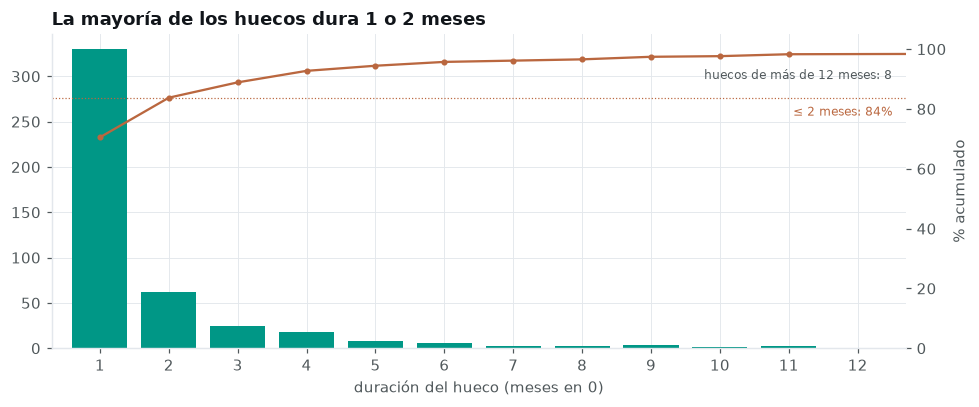

In [4]:
fig, ax = plt.subplots()
ax.bar(dist.index, dist.values, color=VIZ[0])
ax.set_xlabel("duración del hueco (meses en 0)"); ax.set_title("La mayoría de los huecos dura 1 o 2 meses")
ax.set_xlim(0.3, 12.7); ax.set_xticks(range(1, 13))
ax.text(12.5, dist.max() * 0.9, f"huecos de más de 12 meses: {int(dist[dist.index > 12].sum())}", ha="right", fontsize=8, color=MUTED)
ax2 = ax.twinx(); ax2.plot(dist.index, acum.values * 100, color=VIZ[2], marker="o", ms=3); ax2.set_ylim(0, 105)
ax2.set_ylabel("% acumulado"); ax2.grid(False); ax2.spines["top"].set_visible(False)
ax2.axhline(acum.loc[2] * 100, color=VIZ[2], ls=":", lw=0.8)
ax2.text(12.5, acum.loc[2] * 100 - 6, f"≤ 2 meses: {acum.loc[2]:.0%}", ha="right", color=VIZ[2], fontsize=8)
plt.tight_layout()

**Lectura.** Un cliente que deja de pagar un mes y vuelve al siguiente no "se fue y volvió". Si el 84 % de los huecos dura
dos meses o menos, una tolerancia de **N = 2** cubre casi todo el fenómeno sin ocultar el churn real (que termina la serie en 0,
no vuelve). N = 1 y N = 3 quedan como sensibilidad (notebook 04).

## 2. Qué pasa cuando el cliente vuelve a pagar: la puesta al día

In [5]:
filas = []
for cid, g in tx.groupby("cliente"):
    a, meses = g["amount"].to_numpy(), g["month"].to_numpy()
    ultimo, ceros = None, 0
    for i, v in enumerate(a):
        if v > 0:
            if ultimo is not None and ceros > 0:
                filas.append((cid, meses[i], ceros, v / ultimo))
            ultimo, ceros = v, 0
        elif ultimo is not None:
            ceros += 1
vuelta = pd.DataFrame(filas, columns=["cliente", "mes", "hueco", "ratio"])
vuelta["puesta_al_dia"] = np.isclose(vuelta["ratio"], vuelta["hueco"] + 1, rtol=0.01)
print(f"pagos que siguen a un hueco: {len(vuelta)} | exactamente (hueco + 1) × el monto anterior: "
      f"{int(vuelta['puesta_al_dia'].sum())} ({vuelta['puesta_al_dia'].mean():.1%})\n")
print("ratio del pago que sigue a un hueco de 1 mes (valores más frecuentes):")
print(vuelta.loc[vuelta["hueco"] == 1, "ratio"].round(2).value_counts().head(4).to_string(), "\n")
vuelta.groupby("hueco")["puesta_al_dia"].agg(pagos="size", puestas_al_dia="sum", proporcion="mean").head(7).round(3)

pagos que siguen a un hueco: 468 | exactamente (hueco + 1) × el monto anterior: 152 (32.5%)

ratio del pago que sigue a un hueco de 1 mes (valores más frecuentes):
ratio
2.00    117
1.00     87
0.50     56
0.67      3 



,pagos,puestas_al_dia,proporcion
hueco,,,
1,330,120,0.364
2,62,21,0.339
3,24,5,0.208
4,18,1,0.056
5,8,2,0.250
6,6,0,0.000
7,2,1,0.500


In [6]:
ej = vuelta[(vuelta["hueco"] >= 5) & vuelta["puesta_al_dia"]].iloc[0]
g = tx[tx["cliente"] == ej["cliente"]]
print(f"Ejemplo (cliente anonimizado): {int(ej['hueco'])} meses en 0 y luego un pago de {int(ej['hueco']) + 1} × el monto habitual\n")
print(" ".join(f"{m}:{v:g}" for m, v in zip(g["month"].astype(str), g["amount"].round(2))))

Ejemplo (cliente anonimizado): 7 meses en 0 y luego un pago de 8 × el monto habitual

2022-01:12.6 2022-02:0 2022-03:0 2022-04:0 2022-05:0 2022-06:0 2022-07:0 2022-08:0 2022-09:100.8 2022-10:12.6 2022-11:12.6 2022-12:12.6 2023-01:0 2023-02:0 2023-03:0 2023-04:0 2023-05:0 2023-06:0 2023-07:0 2023-08:0 2023-09:0 2023-10:0 2023-11:0 2023-12:0 2024-01:0 2024-02:0 2024-03:0 2024-04:0 2024-05:0 2024-06:0 2024-07:0 2024-08:0 2024-09:0 2024-10:0


**Lectura.** El pago de 2× tras un mes en 0 (o de 8× tras siete meses) es un **cobro de mora**: el cliente estuvo activo
todo el tiempo y pagó después. El modelo de caja lo registra como churn, luego reactivación por el doble y luego contracción a la
mitad: tres movimientos falsos por un cliente que no cambió nada. El otro valor frecuente tras un hueco de 1 mes es 1× (vuelve a
su monto sin pagar el mes perdido): esa mora **no se recuperó**, y en el modelo corregido queda contada como MRR en mora impaga
(18,8 MM en la ventana).

## 3. Lo que hace el modelo actual con esto: 751 churns, la mitad vuelve

In [7]:
s = tx.copy()
s["prev"] = s.groupby("cliente")["amount"].shift(fill_value=0.0)
s["ya_fue_cliente"] = s.groupby("cliente")["amount"].transform(lambda a: (a > 0).cumsum().shift(fill_value=0) > 0)
s["mv"] = np.select(
    [(s["amount"] > 0) & (s["prev"] == 0) & ~s["ya_fue_cliente"],
     (s["amount"] > 0) & (s["prev"] == 0) & s["ya_fue_cliente"],
     (s["amount"] == 0) & (s["prev"] > 0),
     (s["amount"] > s["prev"]) & (s["prev"] > 0),
     (s["amount"] < s["prev"]) & (s["amount"] > 0)],
    ["new", "reactivation", "churn", "expansion", "contraction"], default="flat")
s["delta"] = s["amount"] - s["prev"]
s["n1"] = s.groupby("cliente")["amount"].shift(-1)
s["n2"] = s.groupby("cliente")["amount"].shift(-2)

ch = s[s["mv"] == "churn"]
print(f"eventos de churn del modelo actual: {len(ch)} | vuelven a pagar al mes siguiente: {(ch['n1'] > 0).mean():.1%} "
      f"| en 2 meses o menos: {((ch['n1'] > 0) | (ch['n2'] > 0)).mean():.1%}\n")
puente = (s[s["month"] > pd.Period("2022-01", "M")]
          .pivot_table(index="month", columns="mv", values="delta", aggfunc="sum", fill_value=0.0)
          [["new", "expansion", "reactivation", "contraction", "churn"]])
print("acumulado feb-2022 → oct-2024, en unidades del archivo (× 10.000 = COP):")
print(puente.sum().round(0).astype(int).to_string())

eventos de churn del modelo actual: 751 | vuelven a pagar al mes siguiente: 43.9% | en 2 meses o menos: 52.2%

acumulado feb-2022 → oct-2024, en unidades del archivo (× 10.000 = COP):
mv
new             10548
expansion        4117
reactivation     8650
contraction     -9091
churn           -8024


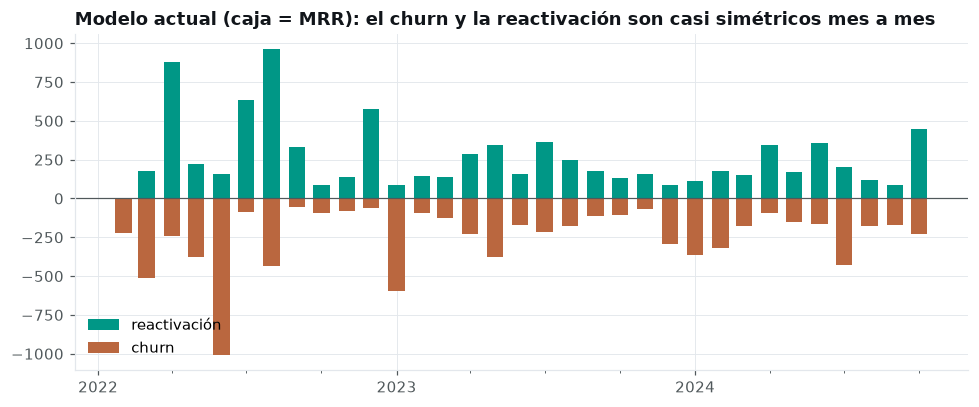

In [8]:
fig, ax = plt.subplots()
x = puente.index.to_timestamp()
ax.bar(x, puente["reactivation"], width=20, color=VIZ[0], label="reactivación")
ax.bar(x, puente["churn"], width=20, color=VIZ[2], label="churn")
ax.axhline(0, color=MUTED, lw=0.8)
ax.set_title("Modelo actual (caja = MRR): el churn y la reactivación son casi simétricos mes a mes")
ax.legend(loc="lower left"); eje_fechas(ax); plt.tight_layout()

**Lectura.** Un churn que en la mitad de los casos vuelve en dos meses no es churn. Y una reactivación acumulada casi igual a
los nuevos no es una máquina de recuperar clientes: es el espejo del churn falso. El modelo está midiendo **cuándo paga la gente**, no
si sigue siendo cliente.

## Conclusión: decisión D1

- Un hueco de **≤ 2 meses**, o un hueco que se paga completo después, mantiene al cliente **activo** con su monto recurrente.
- El exceso de una puesta al día (**k × monto** tras k − 1 ceros) es **cobro de mora**, no expansión, y sale del MRR.
- El churn se **confirma** después de dos meses sin pago; la mora abierta al cierre se marca "en confirmación".
- Fundamento: ChartMogul mantiene las suscripciones morosas en el MRR hasta su cancelación; la dbt MRR playbook usa una malla de
  fechas para capturar churn y reactivación.

El efecto de aplicar esto se mide en el notebook 04: el churn pasa de −72,9 a −18,0 MM y la reactivación de +84,7 a +5,9 MM.

In [9]:
assert KF["huecos"] == len(todos) and KF["huecos_clientes"] == int(con_hueco.sum())
print("coincide con key_figures.csv:", {k: KF[k] for k in ("huecos", "huecos_clientes", "huecos_pct")})

coincide con key_figures.csv: {'huecos': 468.0, 'huecos_clientes': 340.0, 'huecos_pct': 17.0}
